#### Objective Phase: Time-Series Signal Processing & Feature Architecture
- We will move to the second objective from `04_time_series_analysis.ipynb`.

##### 2. **Variance Stabilization (heteroscedasticity) & Target Normalization**

Action: Analyze target distribution over time and identify proper transformations to make it closer to normal distribution.
- The Target (weekly_sales): A store might average $20,000 a week in July, but suddenly print $150,000 during Thanksgiving week.

- The Features (markdowns): These are "zero-inflated." For 40 weeks of the year, a store might have exactly $0 in markdowns. Then, for a clearance event, it spikes to $50,000.

- If we feed these raw numbers into a model, the algorithm will skew. The massive spikes act like black holes, pulling the model's loss function entirely toward the holidays, causing it to perform terribly on normal weeks.

Insight: Visual inspection of the weekly sales over single store and department (granular level) revealed strong level-dependent heteroscedasticity means the variance (spread) changes depending on the value level of the weekly_sales. While secular variance was stable year-over-year, conditional variance scaled proportionally with the mean (tight bands during baseline weeks; explosive spread during holiday peaks).

Impact: If left unaddressed, this heteroscedasticity would warp the XGBoost RMSE loss function, forcing the model to over-index on high-variance holiday outliers. The log transformation stabilizes this conditional variance and compresses the heavy right-tail distribution, allowing the model to learn baseline and promotional patterns symmetrically.

Fix: 
1. log transformation → stabilizes conditional variance + handles right skew
2. store/department level normalisation → removes scale imbalances between entities
3. scaling → ensures all features contribute equally to splits



**Secular variance** 
Overall dataset variance — the total spread of ALL data points together

"How much does the data vary if I look at the entire dataset as one big blob?"

- Stable over time in your chart (no upward trend in overall spread)

- Data shows constant secular variance year‑over‑year

**Conditional variance** (what heteroscedasticity is about)
- Variance within specific conditions* — spread around the local mean

- "Given that we're in a high-sales period, how much does it vary around that high mean?"

- Changes depending on the condition (time, store size, holiday, etc.)

In [13]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import config

In [5]:
sns.set_theme(style='whitegrid')

In [3]:
df = pl.read_parquet(config.GOLD_MASTER_PATH)

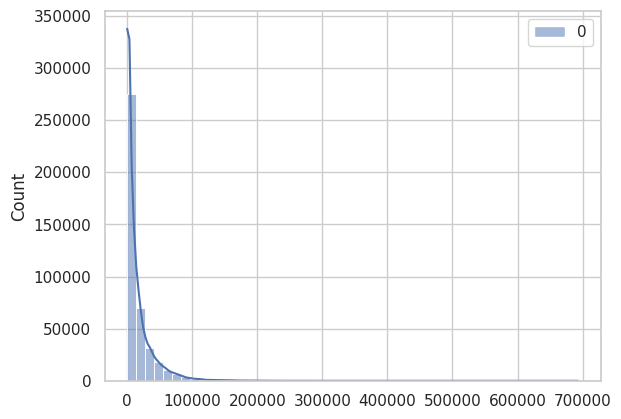

In [17]:
sns.histplot(df.select(pl.col('weekly_sales')), bins=50, kde=True)
plt.show()

In [32]:

result = (
    df
    .group_by("date")
    .agg(
        pl.col("weekly_sales").sum().round(2).cast(pl.Int64).alias("total_weekly_sales")
    )
)

print(result)

shape: (143, 2)
┌────────────┬────────────────────┐
│ date       ┆ total_weekly_sales │
│ ---        ┆ ---                │
│ date       ┆ i64                │
╞════════════╪════════════════════╡
│ 2011-04-22 ┆ 48676782           │
│ 2010-12-03 ┆ 49910639           │
│ 2012-01-06 ┆ 44955766           │
│ 2010-03-19 ┆ 44989431           │
│ 2012-09-21 ┆ 44354937           │
│ …          ┆ …                  │
│ 2010-11-12 ┆ 46124900           │
│ 2012-05-04 ┆ 47124459           │
│ 2011-08-19 ┆ 46917761           │
│ 2010-07-16 ┆ 46243964           │
│ 2011-04-01 ┆ 43459828           │
└────────────┴────────────────────┘


<Axes: xlabel='date', ylabel='weekly_sales'>

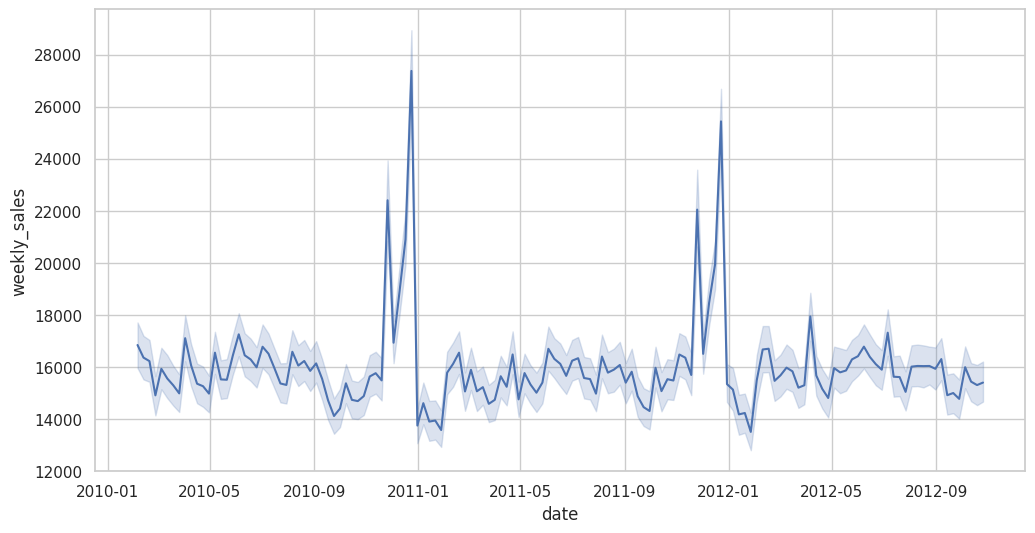

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data = df, x='date', y='weekly_sales')
plt.show()

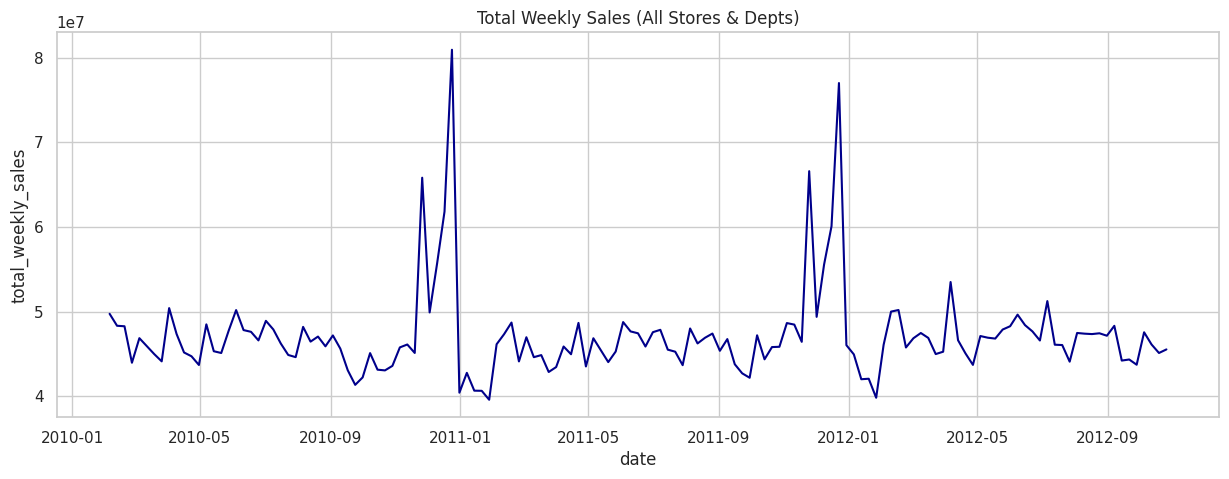

In [ ]:

# Group by date and calculate the SUM of all sales
result = (
    df
    .group_by("date")
    .agg(
        pl.col("weekly_sales").sum().round(2).cast(pl.Int64).alias("total_weekly_sales")
    )
)

plt.figure(figsize=(15, 5))
sns.lineplot(data=result, x='date', y='total_weekly_sales', color='darkblue')
plt.title('Total Weekly Sales (All Stores & Depts)')
plt.show()

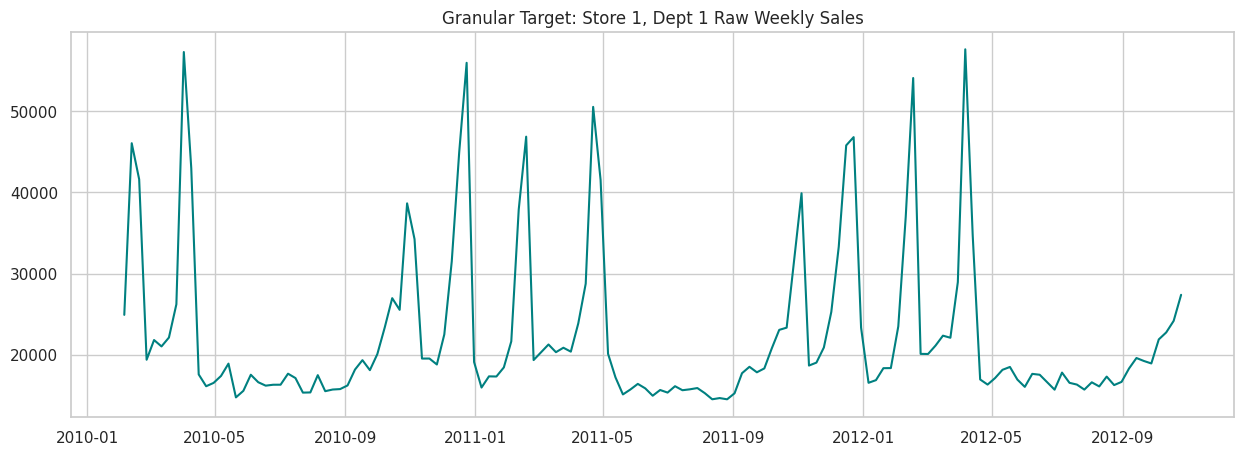

In [37]:
# Filter down to the absolute lowest grain: One Store, One Department
single_dept = df.filter(pl.col('store')==1, pl.col('dept') == 1)
plt.figure(figsize=(15, 5))
# Use standard matplotlib plot to guarantee no background aggregation
plt.plot(single_dept['date'], single_dept['weekly_sales'], color='teal')
plt.title('Granular Target: Store 1, Dept 1 Raw Weekly Sales')
plt.show()